# Smart Energy Analytics

## Notebook 04: Improved LSTM Model

### Project Description

This notebook focuses on improving the baseline Long Short-Term Memory (LSTM) model developed previously for household energy consumption forecasting.

The baseline model provided reasonable predictions, but it tended to smooth the signal and struggled to capture sudden peaks and fluctuations in energy usage.

In this notebook, several improvements will be introduced to increase prediction accuracy and improve the model's ability to learn temporal patterns from historical energy consumption data.

---

## Objectives

The main objectives of this notebook are:

* Improve the baseline LSTM architecture.
* Increase forecasting accuracy.
* Reduce prediction error.
* Capture temporal dependencies more effectively.
* Compare the improved model against the baseline model.

---

## Planned Improvements

The following techniques will be explored:

* Increase the LSTM network depth.
* Increase the number of LSTM units.
* Add Dropout layers to reduce overfitting.
* Tune the learning rate.
* Train for more epochs.
* Experiment with different batch sizes.
* Apply EarlyStopping.
* Save the best model during training.
* Compare evaluation metrics with the baseline model.

---

## Expected Outcome

By the end of this notebook, we expect to obtain:

* Lower MAE
* Lower RMSE
* Higher R² Score
* Better prediction curves
* A more robust forecasting model

---

# Notebook Workflow

1. Import Libraries
2. Load Preprocessed Data
3. Check Dataset Shapes
4. Build Improved LSTM Model
5. Compile the Model
6. Configure Callbacks
7. Train the Model
8. Visualize Training Performance
9. Make Predictions
10. Inverse Scaling
11. Evaluate Performance
12. Plot Actual vs Predicted Values
13. Compare with Baseline Model
14. Save Improved Model

## Section 1 — Import Libraries

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Section 2 — Load Processed Data

In [20]:
X_train = np.load("X_train.npy")
X_test = np.load ('X_test.npy')

y_train = np.load ("y_train.npy")
y_test = np.load ('y_test.npy')

# Section 3: Check Dataset

In [21]:
print("Training Data")

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print()

print("Testing Data")

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

Training Data
X_train : (1098, 60, 7)
y_train : (1098,)

Testing Data
X_test : (275, 60, 7)
y_test : (275,)


In [22]:
print(np.isnan(X_train).sum())
print(np.isnan(X_test).sum())

print(np.isnan(y_train).sum())
print(np.isnan(y_test).sum())

0
0
0
0


# Section 4: Build Improved LSTM Model

In [23]:
model = Sequential()

model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        64,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

model.add(Dense(32, activation="relu"))

model.add(Dense(1))

# Section 5: Model Summary

In [24]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,153 (473.25 KB)

 Trainable params: 121,153 (473.25 KB)

 Non-trainable params: 0 (0.00 B)

# Section 6: Compile Model

In [25]:
optimizer = Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

# Section 7: Training Callbacks

In [26]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "improved_lstm.keras",
    monitor="val_loss",
    save_best_only=True
)

# Section 8: Train Model

In [27]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=100,

    batch_size=32,

    callbacks=[
        early_stop,
        checkpoint
    ],

    verbose=1
)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0161 - mae: 0.0957 - val_loss: 0.0066 - val_mae: 0.0617
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0116 - mae: 0.0818 - val_loss: 0.0064 - val_mae: 0.0609
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0107 - mae: 0.0782 - val_loss: 0.0069 - val_mae: 0.0643
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0109 - mae: 0.0798 - val_loss: 0.0062 - val_mae: 0.0589
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0102 - mae: 0.0766 - val_loss: 0.0067 - val_mae: 0.0632
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0103 - mae: 0.0759 - val_loss: 0.0066 - val_mae: 0.0629
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0105 - mae: 0.0781 - val_loss: 0.0061 - val_mae: 0.0583
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 0.0109 - mae: 0.0793 - val_loss: 0.0063 - val_mae: 0.0598
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - lo

# Section 9: Visualize Training Performance

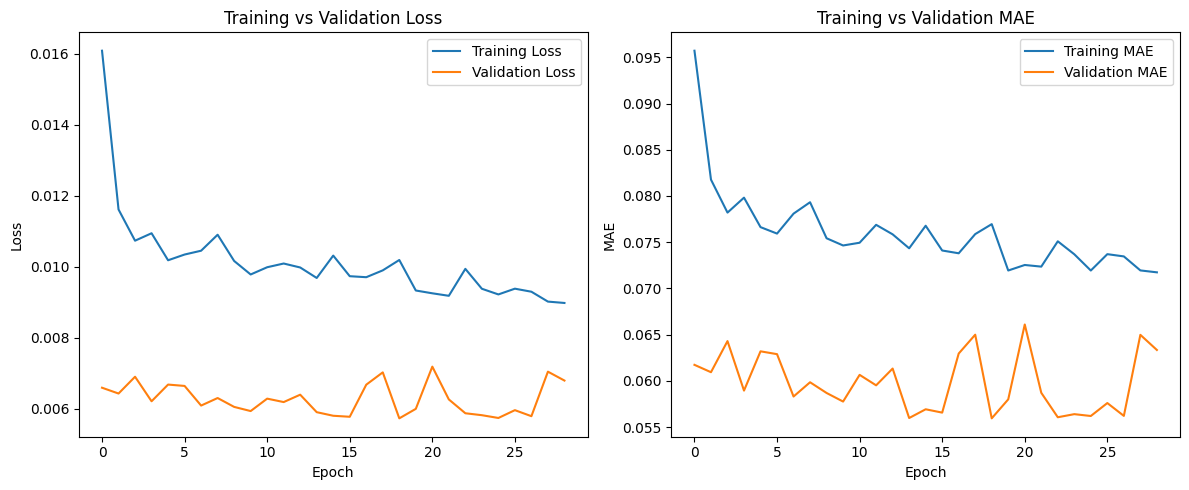

In [29]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

# # Section 10: Generate Predictions

In [30]:
y_pred = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


# Section 11: Evaluate Model Performance

In [31]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.0559
RMSE : 0.0757
R²   : 0.4046


# Section 12: Plot Actual vs Predicted Values

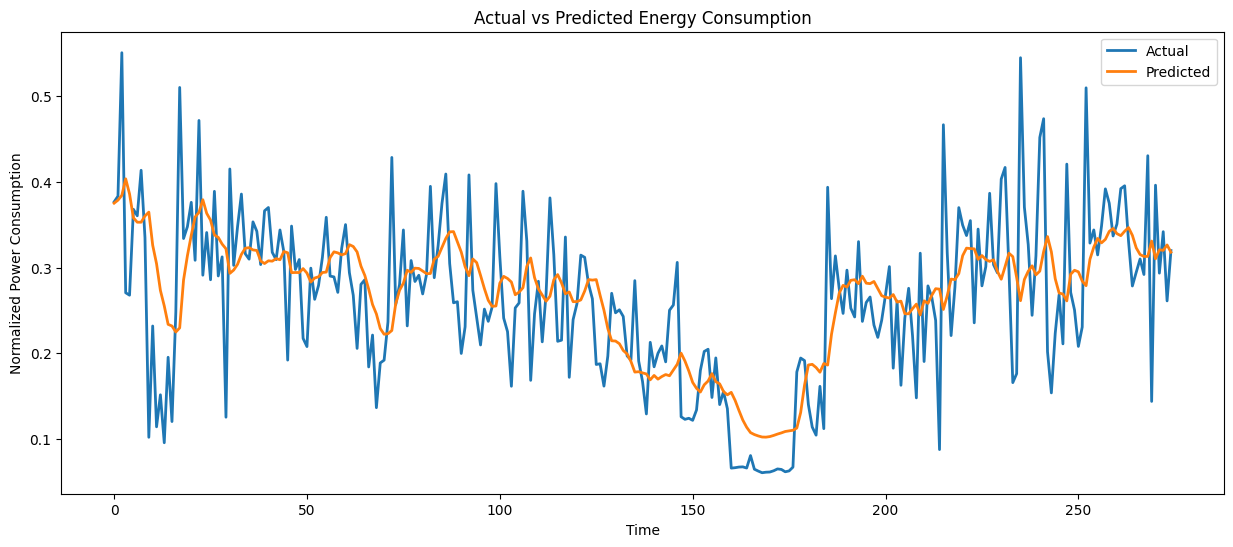

In [32]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test,
    label="Actual",
    linewidth=2
)

plt.plot(
    y_pred,
    label="Predicted",
    linewidth=2
)

plt.title("Actual vs Predicted Energy Consumption")

plt.xlabel("Time")

plt.ylabel("Normalized Power Consumption")

plt.legend()

plt.show()

# Section 13: Compare with Baseline Model

In [35]:
baseline_mae = 0.1915
baseline_rmse = 0.2514
baseline_r2 = 0.3118

comparison = {
    "Metric": ["MAE","RMSE","R²"],
    "Baseline":[baseline_mae, baseline_rmse, baseline_r2],
    "Improved":[mae, rmse, r2]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df



,Metric,Baseline,Improved
0,MAE,0.1915,0.055940
1,RMSE,0.2514,0.075726
2,R²,0.3118,0.404586



# Section 14: Save Improved Model

In [ ]:


model.save("improved_lstm.keras")

print("Improved model saved successfully!")

Improved model saved successfully!


# Section 15: Conclusion

In [38]:
print("Model Improvement Summary")
print("- Improved LSTM model trained successfully.")
print("- Performance evaluated using MAE, RMSE, and R².")
print("- Training curves were analyzed.")
print("- Predictions were compared with actual values.")
print("- Results were compared against the baseline model.")

Model Improvement Summary
- Improved LSTM model trained successfully.
- Performance evaluated using MAE, RMSE, and R².
- Training curves were analyzed.
- Predictions were compared with actual values.
- Results were compared against the baseline model.
